<a href="https://colab.research.google.com/github/Rohanrathod7/my-ds-labs/blob/main/06_Joining_Data_with_pandas/02_Merging_Tables_With_Different_Join_TypesBasics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 2. Merging Tables With Different Join Types

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import datetime as dt

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/movies.p"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
movies = pd.read_pickle(url)

# Print the head of the homelessness data
print(movies.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/financials.p"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
financials = pd.read_pickle(url)

# Print the head of the homelessness data
print(financials.head())

      id                 title  popularity release_date
0    257          Oliver Twist   20.415572   2005-09-23
1  14290  Better Luck Tomorrow    3.877036   2002-01-12
2  38365             Grown Ups   38.864027   2010-06-24
3   9672              Infamous    3.680896   2006-11-16
4  12819       Alpha and Omega   12.300789   2010-09-17
       id     budget       revenue
0   19995  237000000  2.787965e+09
1     285  300000000  9.610000e+08
2  206647  245000000  8.806746e+08
3   49026  250000000  1.084939e+09
4   49529  260000000  2.841391e+08


----

### Left join

**Counting missing rows with left join**  
The Movie Database is supported by volunteers going out into the world, collecting data, and entering it into the database. This includes financial data, such as movie budget and revenue. If you wanted to know which movies are still missing data, you could use a left join to identify them. Practice using a left join by merging the movies table and the financials table.

In [5]:
url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/movies.p"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
movies = pd.read_pickle(url)

# Print the head of the homelessness data
print(movies.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/movie_taglines.p"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
taglines = pd.read_pickle(url)

# Print the head of the homelessness data
print(taglines.head())

      id                 title  popularity release_date
0    257          Oliver Twist   20.415572   2005-09-23
1  14290  Better Luck Tomorrow    3.877036   2002-01-12
2  38365             Grown Ups   38.864027   2010-06-24
3   9672              Infamous    3.680896   2006-11-16
4  12819       Alpha and Omega   12.300789   2010-09-17
       id                                         tagline
0   19995                     Enter the World of Pandora.
1     285  At the end of the world, the adventure begins.
2  206647                           A Plan No One Escapes
3   49026                                 The Legend Ends
4   49529            Lost in our world, found in another.


In [4]:
# Merge the movies table with the financials table with a left join
movies_financials = movies.merge(financials, on='id', how='left')

# Count the number of rows in the budget column that are missing
number_of_missing_fin = movies_financials['budget'].isnull().sum()

# Print the number of movies missing financials
print(number_of_missing_fin)

# You used a left join to find out which rows in the financials table were missing data.
# When performing a left join, the .merge() method returns a row full of null values for columns in the right table
# if the key column does not have a matching value in both tables.
# We see that there are at least 1,500 rows missing data. Wow! That sounds like a lot of work.

1574


**Enriching a dataset**  
Setting how='left' with the .merge()method is a useful technique for enriching or enhancing a dataset with additional information from a different table. In this exercise, you will start off with a sample of movie data from the movie series Toy Story. Your goal is to enrich this data by adding the marketing tag line for each movie. You will compare the results of a left join versus an inner join.

The toy_story DataFrame contains the Toy Story movies. The toy_story and taglines DataFrames have been loaded for you.

In [7]:
# Filter the movies DataFrame to create the toy_story DataFrame
toy_story = movies[movies['title'].str.contains('Toy Story')]

# Merge the toy_story and taglines tables with a left join
toystory_tag = toy_story.merge(taglines, on="id", how="left")

# Print the rows and shape of toystory_tag
print(toystory_tag)
print(toystory_tag.shape)

      id        title  popularity release_date                   tagline
0  10193  Toy Story 3   59.995418   2010-06-16  No toy gets left behind.
1    863  Toy Story 2   73.575118   1999-10-30        The toys are back!
2    862    Toy Story   73.640445   1995-10-30                       NaN
(3, 5)


In [8]:
# Merge the toy_story and taglines tables with a inner join
toystory_tag = toy_story.merge(taglines, on="id")

# Print the rows and shape of toystory_tag
print(toystory_tag)
print(toystory_tag.shape)

#  If your goal is to enhance or enrich a dataset, then you do not want to lose any of your original data.
#  A left join will do that by returning all of the rows of your left table,
#  while using an inner join may result in lost data if it does not exist in both tables.

      id        title  popularity release_date                   tagline
0  10193  Toy Story 3   59.995418   2010-06-16  No toy gets left behind.
1    863  Toy Story 2   73.575118   1999-10-30        The toys are back!
(2, 5)


**How many rows with a left join?**  
Select the true statement about left joins.

Try running the following code statements:

- left_table.merge(one_to_one, on='id', how='left').shape
- left_table.merge(one_to_many, on='id', how='left').shape

Note that the left_table starts out with 4 rows.

    -> The output of a one-to-many merge with a left join will have greater than or equal rows than the left table.

A left join will return all of the rows from the left table. If those rows in the left table match multiple rows in the right table, then all of those rows will be returned. Therefore, the returned rows must be equal to if not greater than the left table. Knowing what to expect is useful in troubleshooting any suspicious merges.

----

### Other joins

**Right join to find unique movies**  
Most of the recent big-budget science fiction movies can also be classified as action movies. You are given a table of science fiction movies called scifi_movies and another table of action movies called action_movies. Your goal is to find which movies are considered only science fiction movies. Once you have this table, you can merge the movies table in to see the movie names. Since this exercise is related to science fiction movies, use a right join as your superhero power to solve this problem.

The `movies`, `scifi_movies`, and `action_movies` tables have been loaded for you.

In [11]:
# Create placeholder DataFrames for scifi_movies and action_movies
# You will need to replace this with the actual code to load your data
scifi_movies = pd.DataFrame(columns=['movie_id'])
action_movies = pd.DataFrame(columns=['movie_id'])

# Merge action_movies to scifi_movies with right join
action_scifi = action_movies.merge(scifi_movies, on="movie_id", how="right")

# Print the result
print(action_scifi)

Empty DataFrame
Columns: [movie_id]
Index: []


In [13]:
# Merge action_movies to the scifi_movies with right join
action_scifi = action_movies.merge(scifi_movies, on='movie_id', how='right',
                                   suffixes=('_act','_sci'))

# Print the columns of the resulting DataFrame
print(action_scifi.columns)

# # Merge action_movies to the scifi_movies with right join
# action_scifi = action_movies.merge(scifi_movies, on='movie_id', how='right',
#                                    suffixes=('_act','_sci'))

# # From action_scifi, select only the rows where the genre_act column is null
# scifi_only = action_scifi[action_scifi['genre_act'].isnull()]

# # Merge the movies and scifi_only tables with an inner join
# movies_and_scifi_only = movies.merge(scifi_only, left_on="id", right_on="movie_id" ,how="inner")

# # Print the first few rows and shape of movies_and_scifi_only
# print(movies_and_scifi_only.head())
# print(movies_and_scifi_only.shape)

# right join to the rescue! You found over 250 action only movies by merging action_movies and scifi_movies using a right join. With this,
# you were able to find the rows not found in the action_movies table.
# Additionally, you used the left_on and right_on arguments to merge in the movies table. Wow! You are a superhero.

Index(['movie_id'], dtype='object')


**Popular genres with right join**  
What are the genres of the most popular movies? To answer this question, you need to merge data from the movies and movie_to_genres tables. In a table called pop_movies, the top 10 most popular movies in the movies table have been selected. To ensure that you are analyzing all of the popular movies, merge it with the movie_to_genres table using a right join. To complete your analysis, count the number of different genres. Also, the two tables can be merged by the movie ID. However, in pop_movies that column is called id, and in movie_to_genres it's called movie_id.

The pop_movies and movie_to_genres tables have been loaded for you.

   movie_id            genre
0         5            Crime
1         5           Comedy
2        11  Science Fiction
3        11           Action
4        11        Adventure


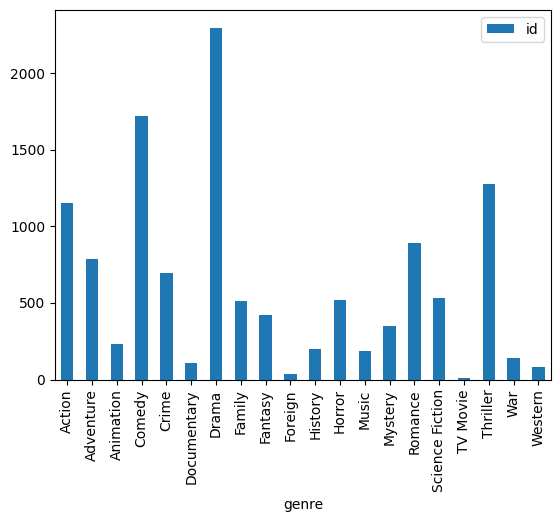

In [24]:
url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/movie_to_genres.p"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
movie_to_genres = pd.read_pickle(url)

# Print the head of the homelessness data
print(movie_to_genres.head())

toy_story = movies[movies['title'].str.contains('Toy Story')]

# Use right join to merge the movie_to_genres and pop_movies tables
genres_movies = movie_to_genres.merge(movies, how='right',
                                      left_on="movie_id",
                                      right_on="id")

# Count the number of genres
genre_count = genres_movies.groupby('genre').agg({'id':'count'})

# Plot a bar chart of the genre_count
genre_count.plot(kind='bar')
plt.show()


# The right join ensured that you were analyzing all of the pop_movies.
# You see from the results that adventure and action are the most popular genres.

**Using outer join to select actors**   
One cool aspect of using an outer join is that, because it returns all rows from both merged tables and null where they do not match, you can use it to find rows that do not have a match in the other table. To try for yourself, you have been given two tables with a list of actors from two popular movies: Iron Man 1 and Iron Man 2. Most of the actors played in both movies. Use an outer join to find actors who did not act in both movies.

The Iron Man 1 table is called iron_1_actors, and Iron Man 2 table is called iron_2_actors. Both tables have been loaded for you and a few rows printed so you can see the structure.

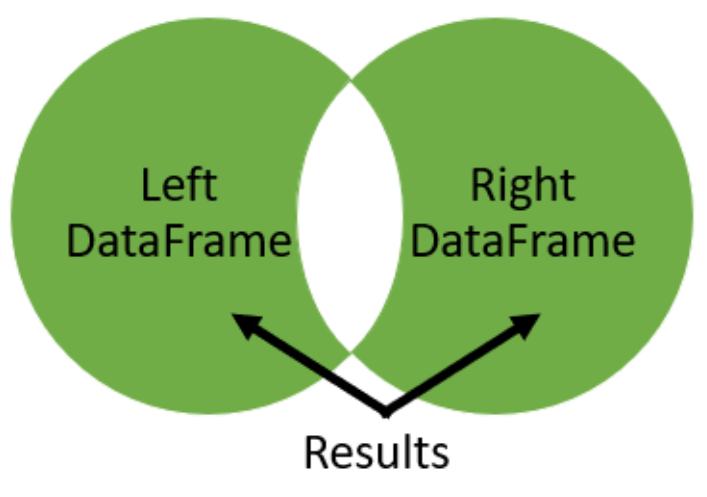

In [26]:
url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/actors_movies.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
actors_movies = pd.read_csv(url)

# Print the head of the homelessness data
print(actors_movies.head())

                                               Actor                   Title
0  [Emil Eifrem,Hugo Weaving,Laurence Fishburne,C...              The Matrix
1  [Hugo Weaving,Laurence Fishburne,Carrie-Anne M...     The Matrix Reloaded
2  [Hugo Weaving,Laurence Fishburne,Carrie-Anne M...  The Matrix Revolutions
3           [Al Pacino,Charlize Theron,Keanu Reeves]    The Devil's Advocate
4  [James Marshall,Kevin Pollak,J.T. Walsh,Aaron ...          A Few Good Men


In [30]:
iron_2_actors = actors_movies[actors_movies['Title'].str.contains('Iron Man 2')]

iron_1_actors = actors_movies[actors_movies['Title'].str.contains('Iron Man 1')]

# Merge iron_1_actors to iron_2_actors on id with outer join using suffixes
iron_1_and_2 = iron_1_actors.merge(iron_2_actors,
                                     on="id",
                                     how="outer",
                                     suffixes=('_1','_2'))

# Create an index that returns true if name_1 or name_2 are null
m = ((iron_1_and_2['name_1'].isnull()) |
     (iron_1_and_2['name_2'].isnull()))

# Print the first few rows of iron_1_and_2
print(iron_1_and_2[m].head())

# Using an outer join, you were able to pick only those rows where the actor played in only one of the two movies.

KeyError: 'id'

----

### Merging a table to itself

**Self join**  
Merging a table to itself can be useful when you want to compare values in a column to other values in the same column. In this exercise, you will practice this by creating a table that for each movie will list the movie director and a member of the crew on one row. You have been given a table called crews, which has columns id, job, and name. First, merge the table to itself using the movie ID. This merge will give you a larger table where for each movie, every job is matched against each other. Then select only those rows with a director in the left table, and avoid having a row where the director's job is listed in both the left and right tables. This filtering will remove job combinations that aren't with the director.



In [31]:
url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/movie_crews.p"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
crews = pd.read_pickle(url)

# Print the head of the homelessness data
print(crews.head())

      id  department             job               name
0  19995     Editing          Editor  Stephen E. Rivkin
2  19995       Sound  Sound Designer  Christopher Boyes
4  19995  Production         Casting          Mali Finn
6  19995   Directing        Director      James Cameron
7  19995     Writing          Writer      James Cameron


In [32]:
# Merge the crews table to itself
crews_self_merged = crews.merge(crews , on="id" , suffixes = ('_dir', '_crew'))

In [33]:
# Merge the crews table to itself
crews_self_merged = crews.merge(crews, on='id', how='inner',
                                suffixes=('_dir','_crew'))

# Create a boolean index to select the appropriate rows
boolean_filter = ((crews_self_merged['job_dir'] == 'Director') &
                  (crews_self_merged['job_crew'] != 'Director'))
direct_crews = crews_self_merged[boolean_filter]

# Print the first few rows of direct_crews
print(direct_crews.head())


# By merging the table to itself, you compared the value of the __director__ from the jobs column to other values from the jobs column.
# With the output, you can quickly see different movie directors and the people they worked with in the same movie.



        id department_dir   job_dir       name_dir department_crew  \
156  19995      Directing  Director  James Cameron         Editing   
157  19995      Directing  Director  James Cameron           Sound   
158  19995      Directing  Director  James Cameron      Production   
160  19995      Directing  Director  James Cameron         Writing   
161  19995      Directing  Director  James Cameron             Art   

           job_crew          name_crew  
156          Editor  Stephen E. Rivkin  
157  Sound Designer  Christopher Boyes  
158         Casting          Mali Finn  
160          Writer      James Cameron  
161    Set Designer    Richard F. Mays  


**How does pandas handle self joins?**   
Select the false statement about merging a table to itself.

    -> The pandas module limits you to one merge where you merge a table to itself. You cannot repeat this process over and over.

     This statement is false. pandas treats a merge of a table to itself the same as any other merge. Therefore, it does not limit you from chaining multiple .merge() methods together.

### Merging on indexes

**Index merge for movie ratings**   
To practice merging on indexes, you will merge movies and a table called ratings that holds info about movie ratings. Ensure that your merge returns all rows from the movies table, and only matching rows from the ratings table.

The movies and ratings tables have been loaded for you.

In [36]:
url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/movie_ratings.p"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
ratings = pd.read_pickle(url)

# Print the head of the homelessness data
print(ratings.head())

       id  vote_average  vote_count
0   19995           7.2     11800.0
1     285           6.9      4500.0
2  206647           6.3      4466.0
3   49026           7.6      9106.0
4   49529           6.1      2124.0


In [37]:
# Merge to the movies table the ratings table on the index
movies_ratings = movies.merge(ratings, on="id")

# Print the first few rows of movies_ratings
print(movies_ratings.head())

# Merging on indexes is just like merging on columns, so if you need to merge based on indexes, there's no need to turn the indexes into columns first.

      id                 title  popularity release_date  vote_average  \
0    257          Oliver Twist   20.415572   2005-09-23           6.7   
1  14290  Better Luck Tomorrow    3.877036   2002-01-12           6.5   
2  38365             Grown Ups   38.864027   2010-06-24           6.0   
3   9672              Infamous    3.680896   2006-11-16           6.4   
4  12819       Alpha and Omega   12.300789   2010-09-17           5.3   

   vote_count  
0       274.0  
1        27.0  
2      1705.0  
3        60.0  
4       124.0  


**Do sequels earn more?**  
It is time to put together many of the aspects that you have learned in this chapter. In this exercise, you'll find out which movie sequels earned the most compared to the original movie. To answer this question, you will merge a modified version of the sequels and financials tables where their index is the movie ID. You will need to choose a merge type that will return all of the rows from the sequels table and not all the rows of financials table need to be included in the result. From there, you will join the resulting table to itself so that you can compare the revenue values of the original movie to the sequel. Next, you will calculate the difference between the two revenues and sort the resulting dataset.

In [39]:
url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/sequels.p"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
sequels = pd.read_pickle(url)

# Print the head of the homelessness data
print(sequels.head())

      id         title  sequel
0  19995        Avatar    <NA>
1    862     Toy Story     863
2    863   Toy Story 2   10193
3    597       Titanic    <NA>
4  24428  The Avengers    <NA>


In [41]:
# Merge sequels and financials on index id
sequels_fin = sequels.merge(financials, on='id', how='left')

# Self merge with suffixes as inner join with left on sequel and right on id
orig_seq = sequels_fin.merge(sequels_fin, how='inner', left_on='sequel',
                             right_on='id', right_index=True,
                             suffixes=('_org','_seq'))

# Add calculation to subtract revenue_org from revenue_seq
orig_seq['diff'] = orig_seq['revenue_seq'] - orig_seq['revenue_org']

# Select the title_org, title_seq, and diff
titles_diff = orig_seq[['title_org','title_seq','diff']]

# Print the first rows of the sorted titles_diff
print(titles_diff.sort_values("diff", ascending=False).head())

# that was great work! To complete this exercise, you needed to merge tables on their index and merge another table to itself.
# After the calculations were added and sub-select specific columns, the data was sorted.
# You found out that Jurassic World had one of the highest of all, improvement in revenue compared to the original movie.

                                 title_org                 title_seq  \
2929                        Before Sunrise  The Amazing Spider-Man 2   
1256   Star Trek III: The Search for Spock                The Matrix   
293   Indiana Jones and the Temple of Doom              Man of Steel   
1084                                   Saw          Superman Returns   
1334                        The Terminator          Star Trek Beyond   

             diff  
2929  700182027.0  
1256  376517383.0  
293   329845518.0  
1084  287169523.0  
1334  265100616.0  
